In [1]:
# import pytorch 
import torch
import torch.nn as nn
import torch.optim as optim

# import other libraries
import tqdm
import matplotlib.pyplot as plt
import numpy as np

# import specific functions
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from torchvision import datasets, transforms


import LAMINAR

In [2]:
class ConvAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_layer_size, num_hidden_layers, bottleneck_size):
        super(ConvAutoencoder, self).__init__()

        # define architecture of the autoencoder
        self.input_size = input_size
        self.hidden_layer_size = hidden_layer_size
        self.num_hidden_layers = num_hidden_layers
        self.bottleneck_size = bottleneck_size

        self.mnist_size = 28

        # construct the encoder and decoder
        self.encoder = self.construct_encoder()
        self.decoder = self.construct_decoder()

        # define loss function and optimizer
        self.loss = nn.MSELoss(reduction='mean')
        self.optimizer = optim.Adam(self.parameters(), lr=0.001)

    def construct_encoder(self):
        # construct the encoder
        encoder = nn.Sequential()

        encoder.add_module('input', nn.Conv2d(self.input_size, self.hidden_layer_size, kernel_size=3, stride=1, padding=1))
        encoder.add_module('relu_input', nn.ReLU())

        for i in range(self.num_hidden_layers - 1):
            encoder.add_module('hidden_' + str(i), nn.Conv2d(self.hidden_layer_size, self.hidden_layer_size, kernel_size=3, stride=1, padding=1))
            encoder.add_module('relu_' + str(i), nn.ReLU())

        # dense bottleneck layer
        encoder.add_module('flatten', nn.Flatten())
        encoder.add_module('bottleneck', nn.Linear(self.hidden_layer_size * self.mnist_size *self.mnist_size, self.bottleneck_size))

        return encoder
    
    def construct_decoder(self):
        # construct the decoder
        decoder = nn.Sequential()

        decoder.add_module('input', nn.Linear(self.bottleneck_size, self.hidden_layer_size * self.mnist_size * self.mnist_size))
        decoder.add_module('reshape', nn.Unflatten(1, (self.hidden_layer_size, self.mnist_size, self.mnist_size)))
        decoder.add_module('relu_input', nn.ReLU())

        for i in range(self.num_hidden_layers - 1):
            decoder.add_module('hidden_' + str(i), nn.Conv2d(self.hidden_layer_size, self.hidden_layer_size, kernel_size=3, stride=1, padding=1))
            decoder.add_module('relu_' + str(i), nn.ReLU())

        decoder.add_module('output', nn.Conv2d(self.hidden_layer_size, self.input_size, kernel_size=3, stride=1, padding=1))

        return decoder
    
    def forward(self, x):
        # forward pass
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [3]:
# define training loop

def train_autoencoder(model, X_train, X_val, n_epochs=10, batch_size=32, verbose=True):
    loss_history = {
        'train': [],
        'val': []
    }
    
    if verbose:
        pbar = tqdm.tqdm(range(n_epochs))
    else:
        pbar = range(n_epochs)

    for epoch in pbar:
        # training
        model.train()
        train_loss = 0
        for i in tqdm.tqdm(range(0, X_train.shape[0], batch_size)):
            batch = X_train[i:i+batch_size]
            model.optimizer.zero_grad()
            output = model(batch)
            loss = model.loss(output, batch)
            loss.backward()
            model.optimizer.step()
            train_loss += loss.item()
        train_loss /= X_train.shape[0]
        loss_history['train'].append(train_loss)

        # validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for i in range(0, X_val.shape[0], batch_size):
                batch = X_val[i:i+batch_size]
                output = model(batch)
                loss = model.loss(output, batch)
                val_loss += loss.item()
        val_loss /= X_val.shape[0]
        loss_history['val'].append(val_loss)

        # print loss
        if verbose:
            pbar.set_description('Epoch: {}/{}, train loss: {:.4f}, val loss: {:.4f}'.format(epoch+1, n_epochs, train_loss, val_loss))
            
    return loss_history

In [4]:

# define function to plot loss history

def plot_loss_history(loss_history):
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    epochs_linspace = np.linspace(1, len(loss_history['train']), len(loss_history['train']))

    ax.scatter(epochs_linspace, loss_history['train'], label='train loss', marker='o')
    ax.scatter(epochs_linspace, loss_history['val'], label='val loss', marker='x')

    ax.plot(epochs_linspace, loss_history['train'])
    ax.plot(epochs_linspace, loss_history['val'])

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')

    ax.set_yscale('log')

    ax.grid(alpha=0.35)
    ax.legend()



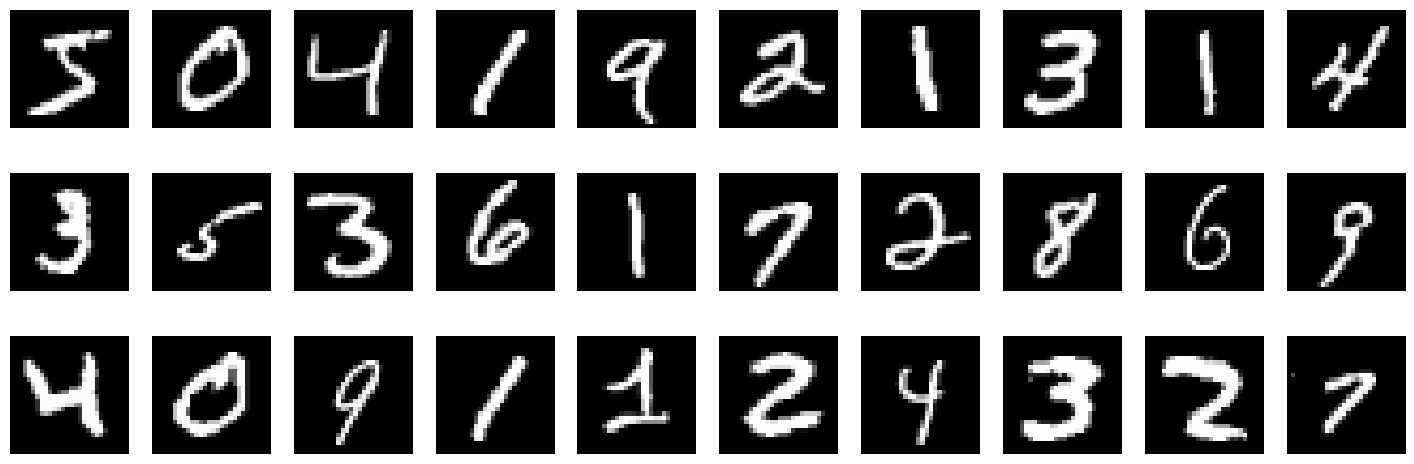

In [5]:
# get MNIST dataset

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mnist_train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

mnist_test_data, mnist_val_data = train_test_split(mnist_test_data, test_size=0.5)

mnist_train = torch.stack([x for x, _ in mnist_train_data])
mnist_test = torch.stack([x for x, _ in mnist_test_data])
mnist_val = torch.stack([x for x, _ in mnist_val_data])

mnist_test_labels = torch.Tensor([y for _, y in mnist_test_data])

# visualise data

fig, ax = plt.subplots(3, 10, figsize=(18, 6))

for i in range(3):
    for j in range(10):
        ax[i, j].imshow(mnist_train[i*10 + j].squeeze(), cmap='gray')
        ax[i, j].axis('off')

### 2D

100%|██████████| 1875/1875 [00:31<00:00, 59.16it/s]  98%|█████████▊| 49/50 [26:07<00:32, 32.43s/it]
Epoch: 50/50, train loss: 0.0052, val loss: 0.0054: 100%|██████████| 50/50 [26:39<00:00, 31.99s/it]


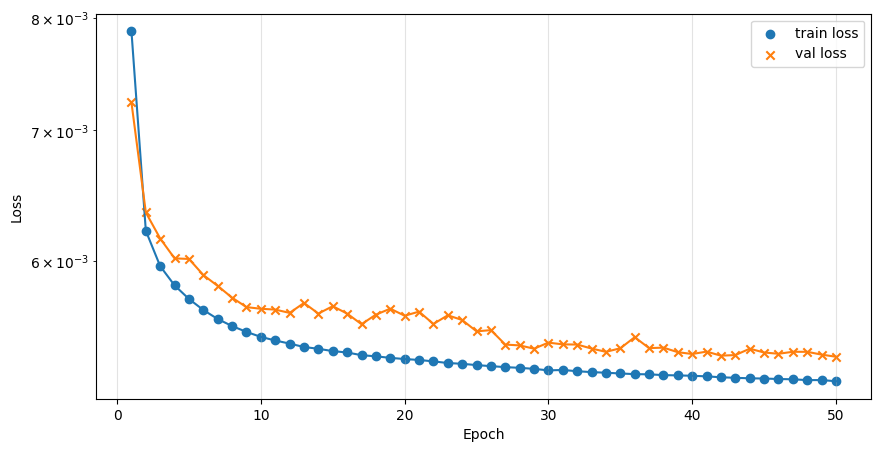

In [6]:
# train autoencoder on MNIST dataset

INPUT_SIZE = 1
BOTTLENECK_SIZE = 2
HIDDEN_SIZE = 8
HIDDEN_LAYERS = 6

TRAIN = True

if TRAIN:
    conv_autoencoder_mnist_2d = ConvAutoencoder(INPUT_SIZE, HIDDEN_SIZE, HIDDEN_LAYERS, BOTTLENECK_SIZE)
    loss_history_mnist = train_autoencoder(conv_autoencoder_mnist_2d, mnist_train, mnist_val, n_epochs=50, batch_size=32)
    plot_loss_history(loss_history_mnist)

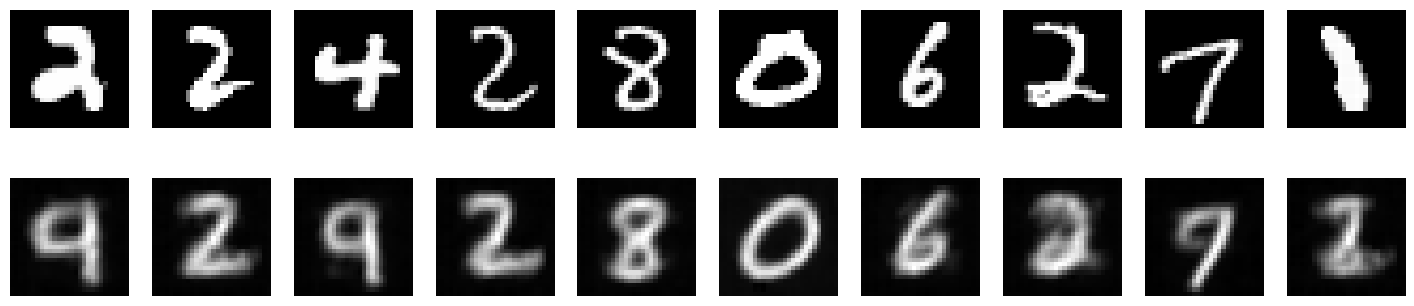

In [7]:
# look at reconstructions of test set

reconstructed_mnist_2d = conv_autoencoder_mnist_2d(mnist_test).detach().numpy()

# compare ground truth and reconstructed data

fig, ax = plt.subplots(2, 10, figsize=(18, 4))

for i in range(10):
    ax[0, i].imshow(mnist_test[i].squeeze(), cmap='gray')
    ax[0, i].axis('off')
    ax[1, i].imshow(reconstructed_mnist_2d[i].squeeze(), cmap='gray')
    ax[1, i].axis('off')



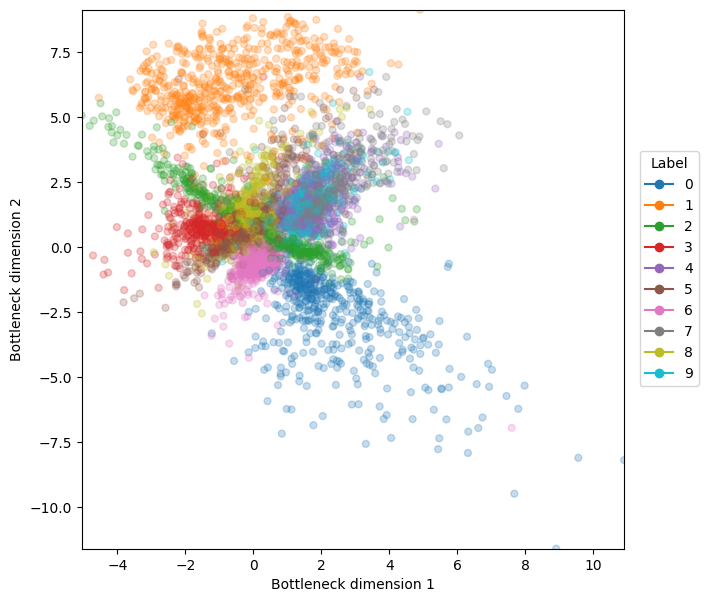

In [8]:
# visualise bottleneck layer with respect to the labels

bottleneck_mnist_2d = conv_autoencoder_mnist_2d.encoder(mnist_test).detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

ax.scatter(bottleneck_mnist_2d[:, 0], bottleneck_mnist_2d[:, 1], c=mnist_test_labels[:], cmap='tab10', alpha=0.25, marker='.', s=100)

ax.set_xlabel('Bottleneck dimension 1')
ax.set_ylabel('Bottleneck dimension 2')

legend_handeles = []   
for i in range(10):
    legend_handeles.append(plt.Line2D([0], [0], marker='o', color=plt.cm.tab10.colors[i], label=str(i)))

ax.legend(handles=legend_handeles, title='Label', loc='upper right', bbox_to_anchor=(1.15, 0.75))

ax.set_xlim([np.min(bottleneck_mnist_2d[:, 0]), np.max(bottleneck_mnist_2d[:, 0])])
ax.set_ylim([np.min(bottleneck_mnist_2d[:, 1]), np.max(bottleneck_mnist_2d[:, 1])]);

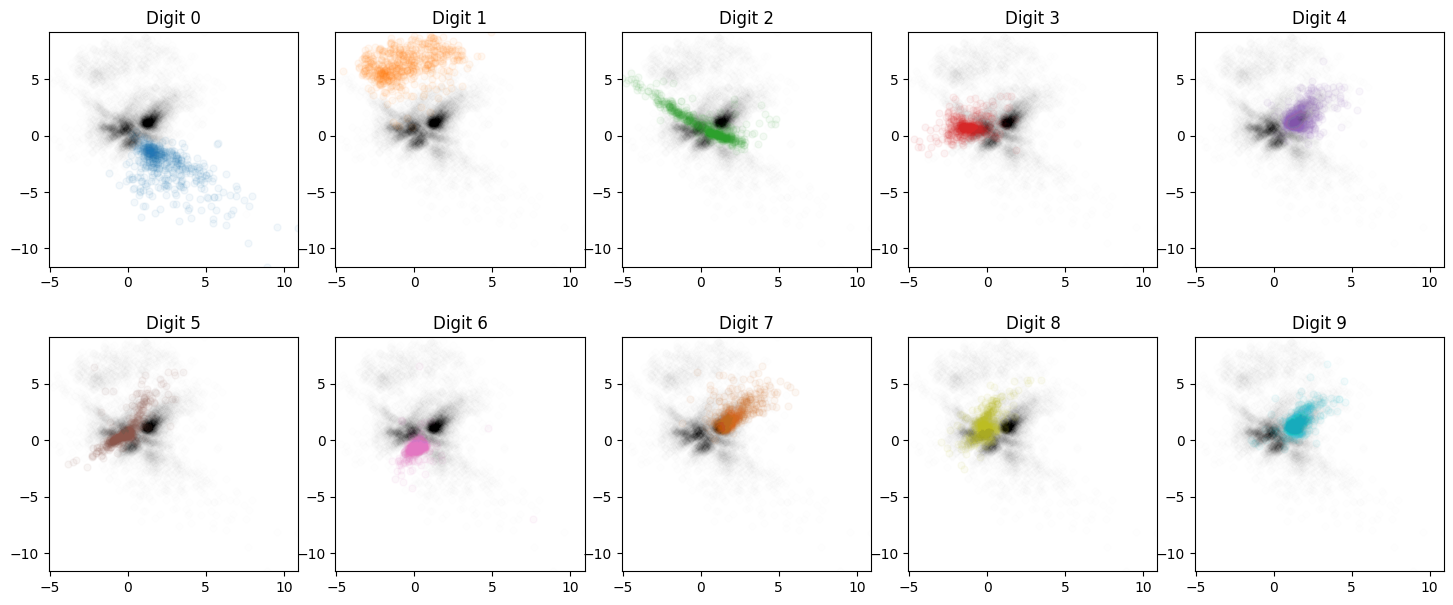

In [9]:
# make subplots for each digit

fig, ax = plt.subplots(2, 5, figsize=(18, 7))

for i in range(10):
    for j in range(10):
        if j != i:
            ax[i//5, i%5].scatter(bottleneck_mnist_2d[mnist_test_labels == j, 0], bottleneck_mnist_2d[mnist_test_labels == j, 1], color='black', alpha=0.005, marker='.', s=100)

    if i != 7:
        ax[i//5, i%5].scatter(bottleneck_mnist_2d[mnist_test_labels == i, 0], bottleneck_mnist_2d[mnist_test_labels == i, 1], color=plt.cm.tab10.colors[i], alpha=0.05, marker='.', s=100)
        ax[i//5, i%5].set_title('Digit {}'.format(i))
    else:
        ax[i//5, i%5].scatter(bottleneck_mnist_2d[mnist_test_labels == i, 0], bottleneck_mnist_2d[mnist_test_labels == i, 1], color='chocolate', alpha=0.05, marker='.', s=100)
        ax[i//5, i%5].set_title('Digit {}'.format(i))

    ax[i//5, i%5].set_xlim([np.min(bottleneck_mnist_2d[:, 0]), np.max(bottleneck_mnist_2d[:, 0])])
    ax[i//5, i%5].set_ylim([np.min(bottleneck_mnist_2d[:, 1]), np.max(bottleneck_mnist_2d[:, 1])])

    fig.subplots_adjust(hspace=0.3)
    fig.subplots_adjust(wspace=0.15)
    

In [10]:
# which pair of points is the furthes apart?
# get euclidean distance matrix
bottleneck_mnist_2d = torch.Tensor(bottleneck_mnist_2d)

distance_matrix = torch.cdist(bottleneck_mnist_2d, bottleneck_mnist_2d, p=2)
distance_matrix = distance_matrix.numpy()

# find the top 0.05 quantile value
quantile_value = np.quantile(distance_matrix, 0.99)

# sample random points from the distance matrix and accept if the distance is greater than the quantile value
while True:
    i = np.random.randint(0, bottleneck_mnist_2d.shape[0])
    j = np.random.randint(0, bottleneck_mnist_2d.shape[0])
    if distance_matrix[i, j] > quantile_value:
        print('Found points with distance greater than quantile value: {} > {}'.format(distance_matrix[i, j], quantile_value))
        print('i: {}, j: {}'.format(i, j))
        break

a = bottleneck_mnist_2d[i]
b = bottleneck_mnist_2d[j]

Found points with distance greater than quantile value: 11.215841293334961 > 10.464814186096191
i: 540, j: 577


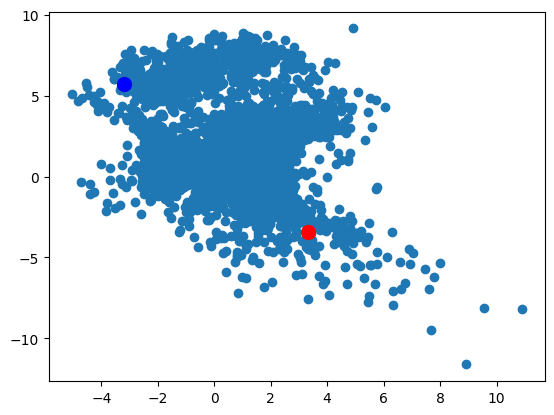

In [11]:
plt.scatter(bottleneck_mnist_2d[:, 0], bottleneck_mnist_2d[:, 1])

plt.scatter(a[0], a[1], color='red', label='point 1', s=100)
plt.scatter(b[0], b[1], color='blue', label='point 2', s=100)

In [12]:
LAM = LAMINAR.LAMINAR(bottleneck_mnist_2d, drop_freq=9999, epochs=1500, save_distance_matrix=False)

Iteration 0 | Train Loss: 1085.1292573242188 | Validation Loss: 520.591796875
Iteration 99 | Train Loss: 390.0095505371094 | Validation Loss: 398.12451171875
Iteration 199 | Train Loss: 385.05280053710936 | Validation Loss: 393.2543640136719
Iteration 299 | Train Loss: 382.90437084960945 | Validation Loss: 392.9239501953125
Iteration 399 | Train Loss: 392.5810710449219 | Validation Loss: 401.4517822265625
Iteration 499 | Train Loss: 382.4396259765625 | Validation Loss: 391.98614501953125
Iteration 599 | Train Loss: 381.0891337890625 | Validation Loss: 391.5177307128906
Iteration 699 | Train Loss: 380.6067536621094 | Validation Loss: 390.9122009277344
Iteration 799 | Train Loss: 382.0039694824219 | Validation Loss: 391.69635009765625
Iteration 899 | Train Loss: 394.0560646972656 | Validation Loss: 398.6293640136719
Iteration 999 | Train Loss: 380.413185546875 | Validation Loss: 392.4674377441406
Iteration 1099 | Train Loss: 380.6839150390625 | Validation Loss: 391.5716247558594
Iteratio

In [13]:
# straight line interpolation
path_straight_2d = torch.linspace(0, 1, 91).unsqueeze(1) * (b - a) + a

interpolation_straight_2d = conv_autoencoder_mnist_2d.decoder(path_straight_2d).detach().numpy()

In [14]:
_, _, path_smooth_2d = LAM.distance_smooth(a, b, n=91)
interpolation_smooth_2d = conv_autoencoder_mnist_2d.decoder(path_smooth_2d).detach().numpy()

Learning rate reduced to 1e-05
Learning rate reduced to 1.0000000000000002e-06
Learning rate reduced to 1.0000000000000002e-07
Learning rate reduced to 1.0000000000000004e-08
Learning rate reduced to 1.0000000000000005e-09
Final loss: 0.01733442209661007
Learning rate reduced to 1.0000000000000002e-06
Learning rate reduced to 1.0000000000000002e-07
Learning rate reduced to 1.0000000000000004e-08
Learning rate reduced to 1.0000000000000005e-09
Best loss: 139.67359924316406
Final loss: 139.67359924316406


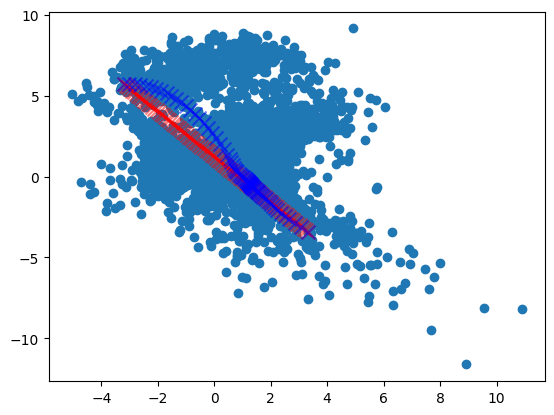

In [15]:
plt.scatter(bottleneck_mnist_2d[:, 0], bottleneck_mnist_2d[:, 1])

plt.scatter(path_straight_2d[:, 0], path_straight_2d[:, 1], color='red', alpha=0.5, marker='x', s=100)
plt.scatter(path_smooth_2d[:, 0], path_smooth_2d[:, 1], color='blue', alpha=0.5, marker='x', s=100)

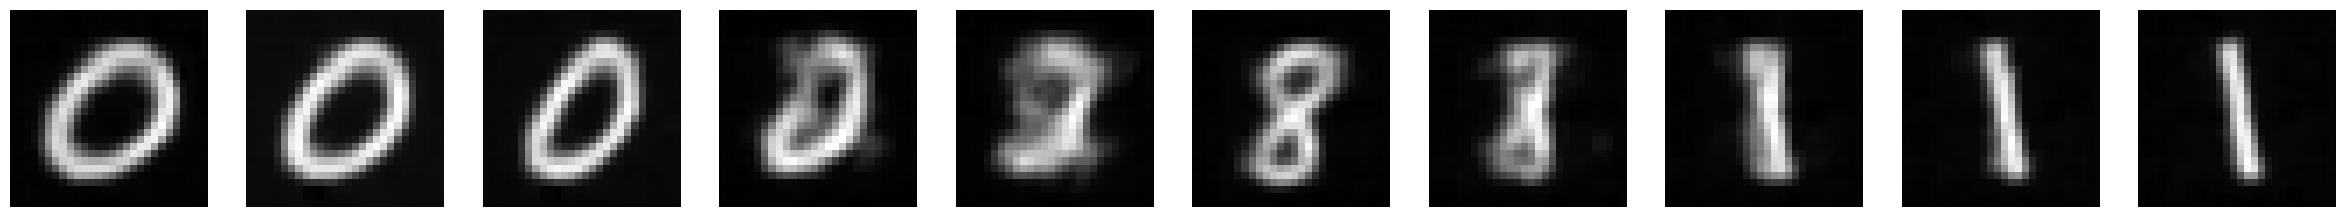

In [16]:
# plot the 10 images
fig, ax = plt.subplots(1, 10, figsize=(30, 3))

for i in range(10):
    ax[i].imshow(interpolation_straight_2d[i*10].squeeze(), cmap='gray')
    ax[i].axis('off')

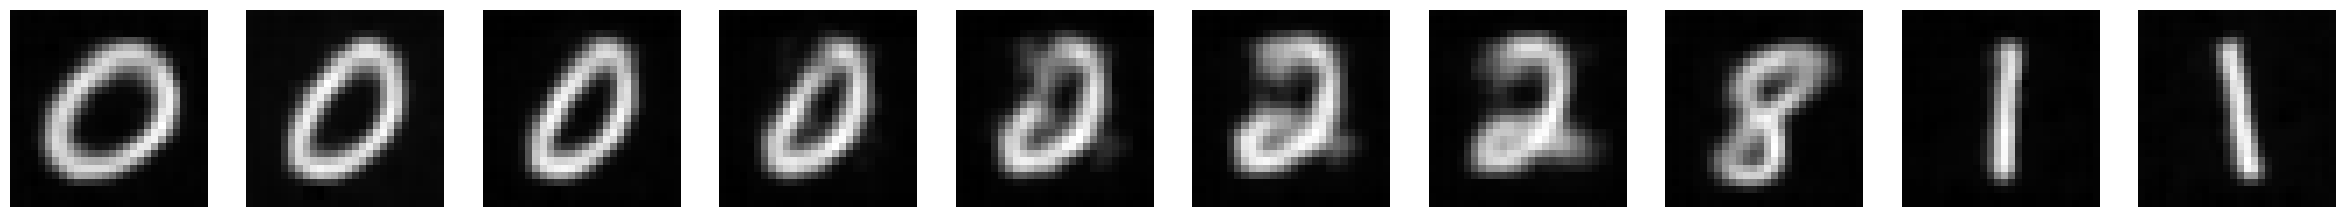

In [17]:
fig, ax = plt.subplots(1, 10, figsize=(30, 3))

for i in range(10):
    ax[i].imshow(interpolation_smooth_2d[i*10].squeeze(), cmap='gray')
    ax[i].axis('off')

### Higher latent space dimensions

100%|██████████| 1875/1875 [00:30<00:00, 61.73it/s]  98%|█████████▊| 49/50 [26:57<00:31, 31.86s/it]
Epoch: 50/50, train loss: 0.0035, val loss: 0.0040: 100%|██████████| 50/50 [27:28<00:00, 32.97s/it]


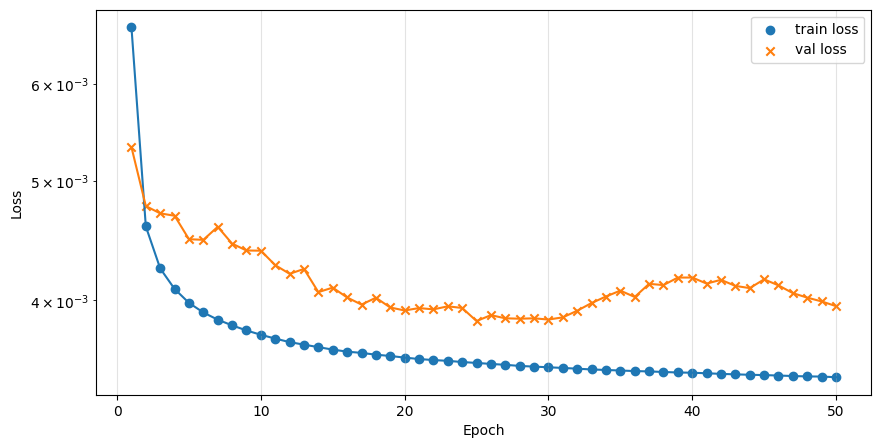

In [33]:
INPUT_SIZE = 1
BOTTLENECK_SIZE = 4
HIDDEN_SIZE = 8
HIDDEN_LAYERS = 6

TRAIN = True

if TRAIN:
    conv_autoencoder_mnist = ConvAutoencoder(INPUT_SIZE, HIDDEN_SIZE, HIDDEN_LAYERS, BOTTLENECK_SIZE)
    loss_history_mnist = train_autoencoder(conv_autoencoder_mnist, mnist_train, mnist_val, n_epochs=50, batch_size=32)
    plot_loss_history(loss_history_mnist)

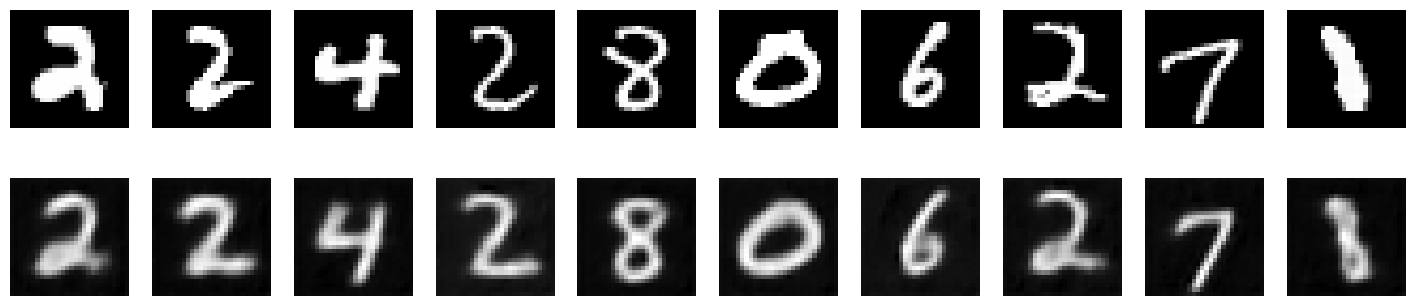

In [34]:
# look at reconstructions of test set

reconstructed_mnist = conv_autoencoder_mnist(mnist_test).detach().numpy()

# compare ground truth and reconstructed data

fig, ax = plt.subplots(2, 10, figsize=(18, 4))

for i in range(10):
    ax[0, i].imshow(mnist_test[i].squeeze(), cmap='gray')
    ax[0, i].axis('off')
    ax[1, i].imshow(reconstructed_mnist[i].squeeze(), cmap='gray')
    ax[1, i].axis('off')



In [35]:
bottleneck_mnist = conv_autoencoder_mnist.encoder(mnist_test).detach()

In [56]:
# which pair of points is the furthes apart?
# get euclidean distance matrix

distance_matrix = torch.cdist(bottleneck_mnist, bottleneck_mnist, p=2)
distance_matrix = distance_matrix.numpy()

# find the top 0.05 quantile value
quantile_value = np.quantile(distance_matrix, 0.99)

# sample random points from the distance matrix and accept if the distance is greater than the quantile value
while True:
    i = np.random.randint(0, bottleneck_mnist.shape[0])
    j = np.random.randint(0, bottleneck_mnist.shape[0])
    if distance_matrix[i, j] > quantile_value:
        print('Found points with distance greater than quantile value: {} > {}'.format(distance_matrix[i, j], quantile_value))
        print('i: {}, j: {}'.format(i, j))
        break

a = bottleneck_mnist[i]
b = bottleneck_mnist[j]

Found points with distance greater than quantile value: 12.445170402526855 > 9.706259765625006
i: 1302, j: 1285


In [37]:
bottleneck_mnist = torch.Tensor(bottleneck_mnist)

In [38]:
LAM = LAMINAR.LAMINAR(bottleneck_mnist, drop_freq=9999, epochs=750, save_distance_matrix=False)

Iteration 0 | Train Loss: 1417.1686103515626 | Validation Loss: 859.5440673828125
Iteration 99 | Train Loss: 687.4800219726562 | Validation Loss: 697.1334228515625
Iteration 199 | Train Loss: 675.8274521484375 | Validation Loss: 700.5492553710938
Iteration 299 | Train Loss: 670.8747705078125 | Validation Loss: 703.24853515625
Iteration 399 | Train Loss: 671.1154960937499 | Validation Loss: 703.222412109375
Iteration 499 | Train Loss: 666.7213198242188 | Validation Loss: 704.024169921875
Iteration 599 | Train Loss: 668.5451098632813 | Validation Loss: 705.9892578125
Early stopping at iteration 599


In [57]:
## straight line interpolation
path_straight = torch.linspace(0, 1, 91).unsqueeze(1) * (b - a) + a

interpolation_straight = conv_autoencoder_mnist.decoder(path_straight).detach().numpy()

In [58]:
_, _, path_smooth = LAM.distance_smooth(a, b, n=91)
interpolation_smooth = conv_autoencoder_mnist.decoder(path_smooth).detach().numpy()

Learning rate reduced to 1e-05
Learning rate reduced to 1.0000000000000002e-06
Learning rate reduced to 1.0000000000000002e-07
Learning rate reduced to 1.0000000000000004e-08
Learning rate reduced to 1.0000000000000005e-09
Final loss: 0.039983462542295456
Learning rate reduced to 1.0000000000000002e-06
Learning rate reduced to 1.0000000000000002e-07
Learning rate reduced to 1.0000000000000004e-08
Learning rate reduced to 1.0000000000000005e-09
Best loss: 753.1361083984375
Final loss: 753.1361083984375


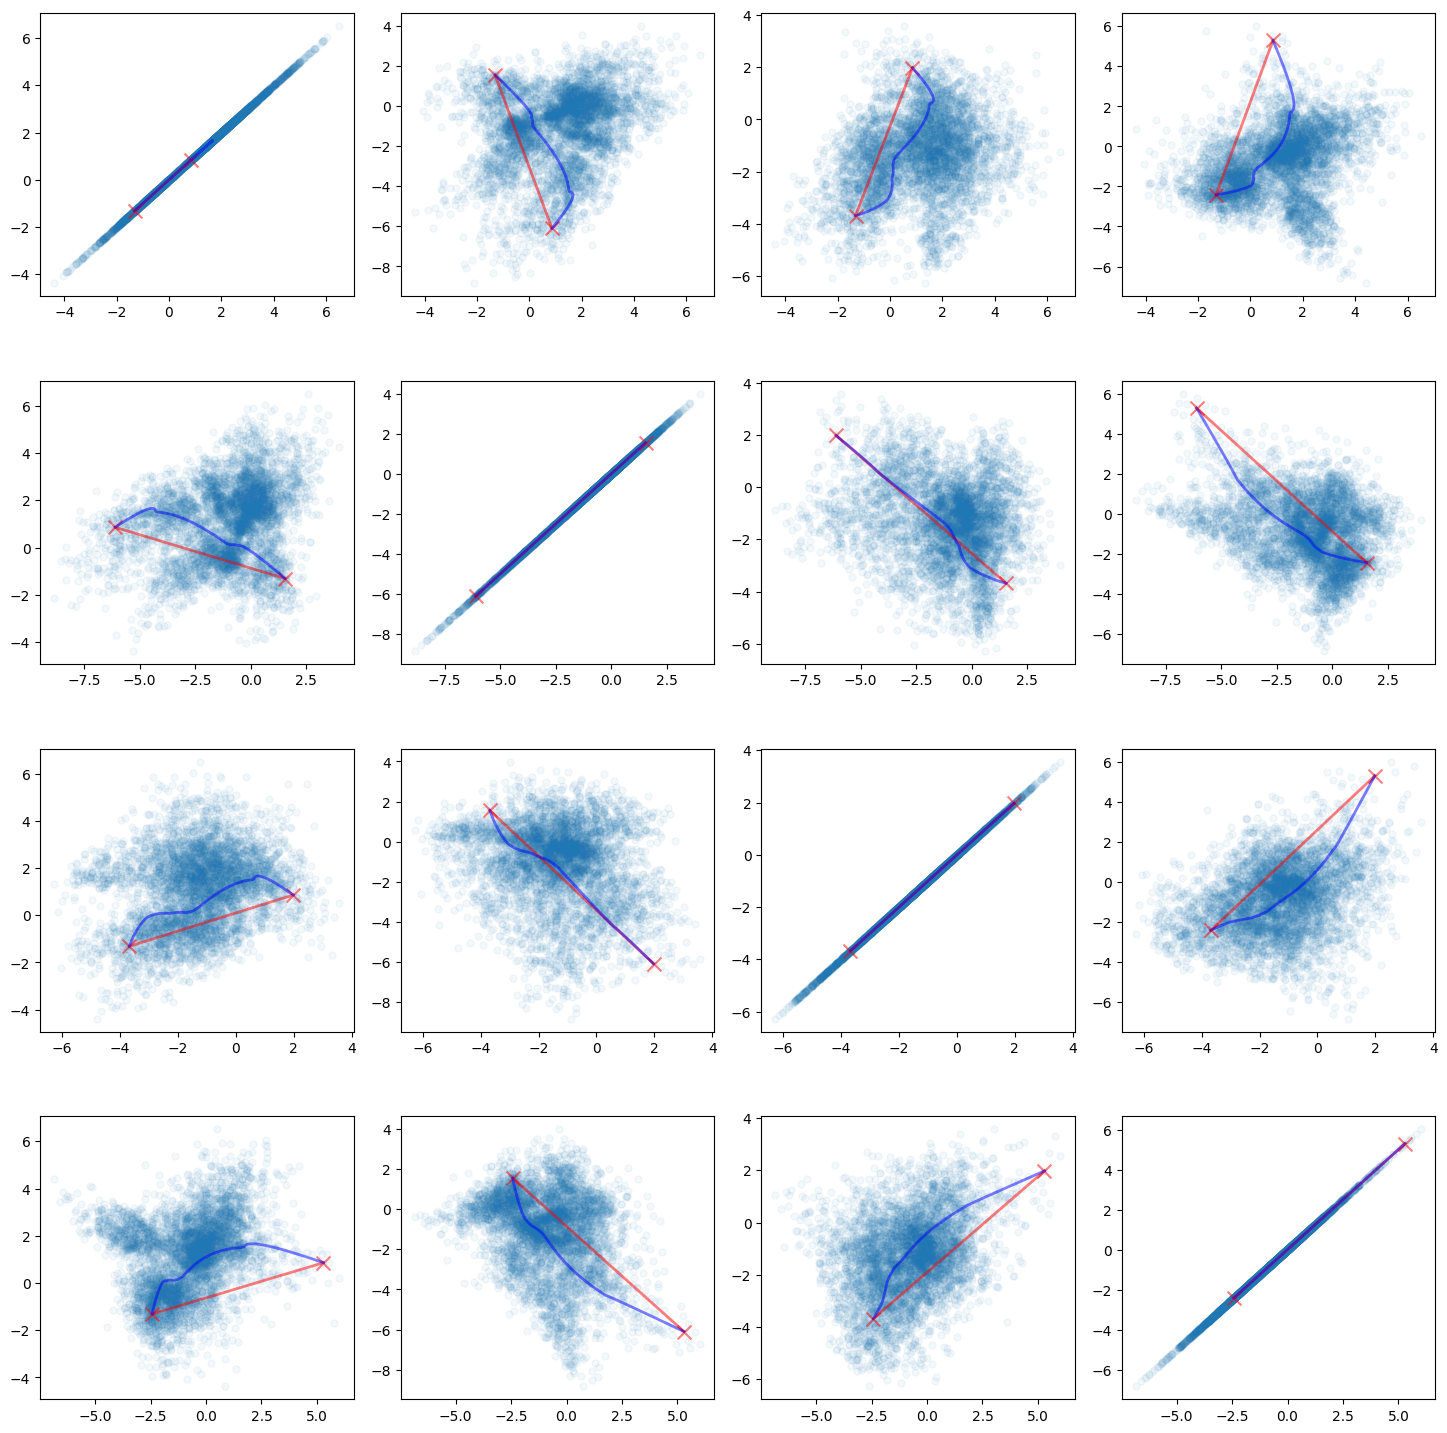

In [59]:
# plot 4x4 subplots for every dimension

# also get the path in the high deimensional case and plot it

fig, ax = plt.subplots(4, 4, figsize=(18, 18))

for i in range(4):
    for j in range(4):
        ax[i, j].scatter(bottleneck_mnist[:, i], bottleneck_mnist[:, j], alpha=0.05, marker='.', s=100)
            
        ax[i, j].scatter(a[i], a[j], color='red', alpha=0.5, marker='x', s=100)
        ax[i, j].scatter(b[i], b[j], color='red', alpha=0.5, marker='x', s=100)

        ax[i, j].plot(path_straight[:, i], path_straight[:, j], color='red', alpha=0.5, linewidth=2)
        ax[i, j].plot(path_smooth[:, i], path_smooth[:, j], color='blue', alpha=0.5, linewidth=2)

        fig.subplots_adjust(hspace=0.3)
        fig.subplots_adjust(wspace=0.15)

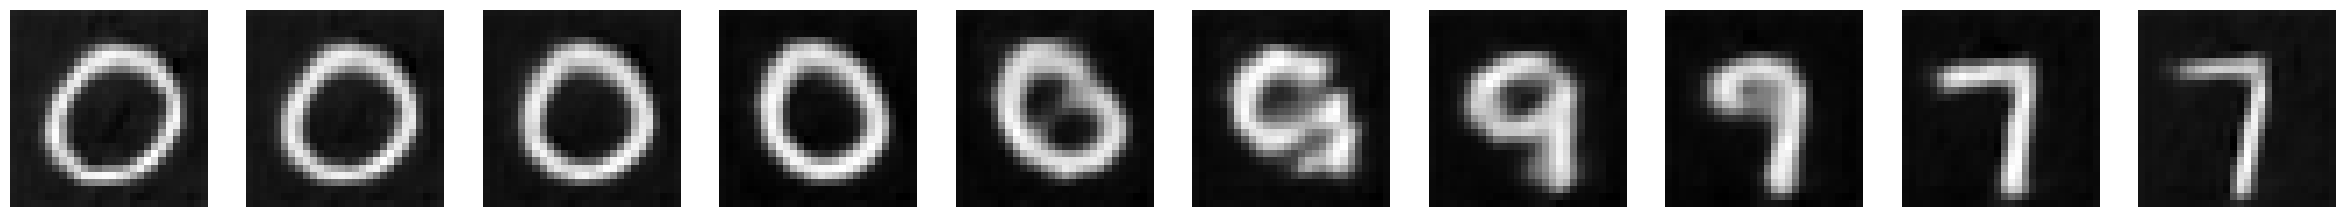

In [60]:
# plot the 10 images
fig, ax = plt.subplots(1, 10, figsize=(30, 3))

for i in range(10):
    ax[i].imshow(interpolation_straight[i*10].squeeze(), cmap='gray')
    ax[i].axis('off')

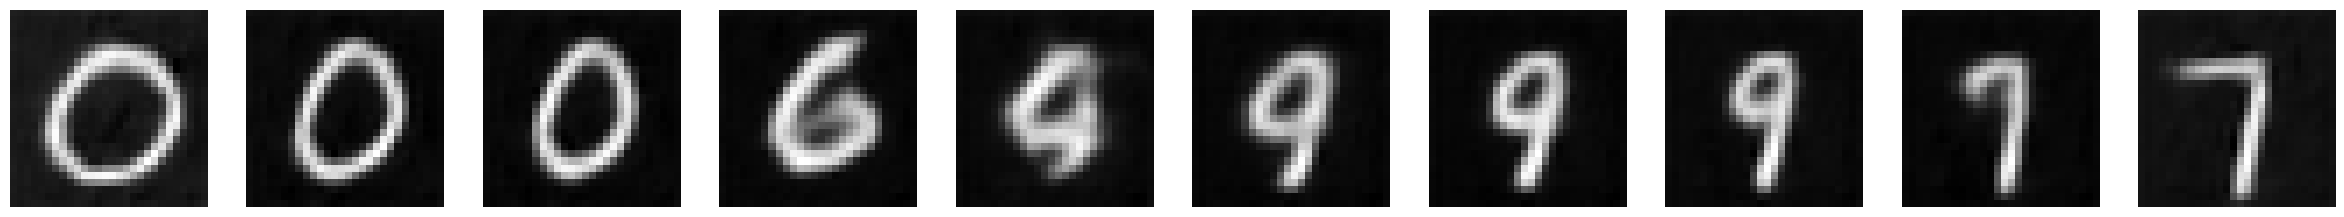

In [61]:
fig, ax = plt.subplots(1, 10, figsize=(30, 3))

for i in range(10):
    ax[i].imshow(interpolation_smooth[i*10].squeeze(), cmap='gray')
    ax[i].axis('off')